# Proprioceptive sensing — object stiffness estimation

$C_A = 1/\lambda_{max}(K_x)$: finger compliance from the analytic VMC stiffness map. $C_O = \|\Delta x\|/\|\Delta F\|$: object compliance from finite-difference across the $k_{tip}$ sweep. Their gap enables proprioceptive exteroception.

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
import matplotlib as mpl

sys.path.insert(0, os.path.join('..'))
plt.style.use(os.path.join('..', 'plot_config.mplstyle'))

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

# Okabe-Ito colorblind-safe palette
CB = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
# orange, sky-blue, bluish-green, yellow, blue, vermillion, reddish-purple, black

# For k_tip gradations (up to 3 sweep levels → sky-blue, vermillion, black)
CB_RADAR = ['#56B4E9', '#D55E00', '#000000']

# Pull experiment constants from the run script (single source of truth)
_ns = {}
with open('object_stiffness_hand.py') as _f:
    for _line in _f:
        if _line.startswith(('K_TIP_GENTLE', 'K_TIP_SWEEP', 'OBJECTS', 'FINGERTIPS')):
            exec(_line, _ns)
K_TIP_GENTLE = float(_ns['K_TIP_GENTLE'])
K_TIP_SWEEP  = [float(k) for k in _ns['K_TIP_SWEEP']]
OBJECTS      = _ns['OBJECTS']
FINGERS      = _ns['FINGERTIPS']

OBJECT_LABELS = ['Sphere', 'Helyx', 'Sponge']

def latest_run(object_name):
    path = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{object_name}.csv')
    return path if os.path.exists(path) else None


In [184]:
def steady_state(df):
    """Group by k_tip and reduce to one steady-state value per finger."""
    out = {}
    for k_tip, sub in df.groupby('k_tip_Npm'):
        per_finger = {}
        for f in FINGERS:
            pos  = sub[[f'tip_{f}_x_m', f'tip_{f}_y_m', f'tip_{f}_z_m']].median().to_numpy()
            ref  = sub[[f'ref_{f}_x_m', f'ref_{f}_y_m', f'ref_{f}_z_m']].median().to_numpy()
            F1   = sub[[f'force_1st_{f}_x_N', f'force_1st_{f}_y_N', f'force_1st_{f}_z_N']].median().to_numpy()
            F2   = sub[[f'force_2nd_{f}_x_N', f'force_2nd_{f}_y_N', f'force_2nd_{f}_z_N']].median().to_numpy()
            eig1 = sub[[f'stiff_1st_{f}_eig_0_Npm', f'stiff_1st_{f}_eig_1_Npm', f'stiff_1st_{f}_eig_2_Npm']].median().to_numpy()
            eig2 = sub[[f'stiff_2nd_{f}_eig_0_Npm', f'stiff_2nd_{f}_eig_1_Npm', f'stiff_2nd_{f}_eig_2_Npm']].median().to_numpy()
            per_finger[f] = dict(pos=pos, ref=ref, F1=F1, F2=F2, eig1=eig1, eig2=eig2)
        out[float(k_tip)] = per_finger
    return out


def object_compliance(ss, finger):
    """C_O ≈ ||Δx|| / ||ΔF|| from the gentle baseline at each k_tip level."""
    k_levels = sorted(k for k in ss.keys() if abs(k - K_TIP_GENTLE) > 1e-6)
    if K_TIP_GENTLE not in ss:
        return np.array(k_levels), np.full(len(k_levels), np.nan)
    pos_b = ss[K_TIP_GENTLE][finger]['pos']
    F_b   = ss[K_TIP_GENTLE][finger]['F1']
    C = []
    for k in k_levels:
        d_pos = ss[k][finger]['pos'] - pos_b
        d_F   = ss[k][finger]['F1']  - F_b
        nF    = np.linalg.norm(d_F)
        C.append(np.linalg.norm(d_pos) / nF if nF > 1e-12 else np.nan)
    return np.array(k_levels), np.array(C)


def finger_compliance(ss, finger, order='1st'):
    """C_A = 1/λ_max(K_x) per k_tip level."""
    levels = sorted(ss.keys())
    C = []
    key = 'eig1' if order == '1st' else 'eig2'
    for k in levels:
        e_max = ss[k][finger][key].max()
        C.append(1.0 / e_max if e_max > 1e-12 else np.nan)
    return np.array(levels), np.array(C)


# Load latest run per object
data = {}
print('Loading data:')
for obj in OBJECTS:
    f = latest_run(obj)
    if f is None:
        print(f'  {obj:<10s}: no data')
        continue
    df = pd.read_csv(f)
    ss = steady_state(df)
    data[obj] = dict(df=df, ss=ss, file=f)
    print(f'  {obj:<10s}: {os.path.basename(f)} — k_tip levels {sorted(ss.keys())}')

Loading data:
  object_1  : object_stiffness_hand_object_1.csv — k_tip levels [10.0, 30.0, 50.0, 70.0]
  object_2  : object_stiffness_hand_object_2.csv — k_tip levels [10.0, 30.0, 50.0, 70.0]
  object_3  : object_stiffness_hand_object_3.csv — k_tip levels [10.0, 30.0, 50.0, 70.0]


In [185]:
W  = 9

header = f"{'':22} " + "  ".join(f"{f.upper():>{W}}" for f in FINGERS) + f"  {'MEAN':>{W}}"

for oi, obj in enumerate(OBJECTS):
    if obj not in data:
        continue
    lbl   = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
    ss    = data[obj]['ss']
    base  = {f: ss[K_TIP_GENTLE][f]['pos'] for f in FINGERS}
    sweep = sorted(k for k in ss if abs(k - K_TIP_GENTLE) > 1e-6)

    print(f"\n{'─'*85}")
    print(f"  {lbl}")
    print(f"{'─'*85}")

    # --- 1. DISPLACEMENT ||Δx|| [mm] ---
    print(f"\n  displacement ||Δx|| [mm]")
    print(header)
    for k in sweep:
        mags_abs = [np.linalg.norm((ss[k][f]['pos'] - base[f]) * 1e3) for f in FINGERS]
        row = "  ".join(f"{m:>{W}.2f}" for m in mags_abs)
        print(f"    k_tip={k:>5.0f} N/m   {row}  {np.mean(mags_abs):>{W}.2f}")

    # --- 2. FORCE [N] ---
    print(f"\n  force [N]")
    print(header)
    for k in sorted(ss):
        vals = [np.linalg.norm(ss[k][f]['F1']) for f in FINGERS]
        row  = "  ".join(f"{v:>{W}.3f}" for v in vals)
        print(f"    k_tip={k:>5.0f} N/m   {row}  {np.mean(vals):>{W}.3f}")

    # --- 3. OBJECT COMPLIANCE C_O [m/N] ---
    print(f"\n  compliance C_O [m/N]")
    print(header)
    for k in sweep:
        vals = []
        for f in FINGERS:
            d_pos = ss[k][f]['pos'] - base[f] 
            d_F   = ss[k][f]['F1']  - ss[K_TIP_GENTLE][f]['F1']
            nF    = np.linalg.norm(d_F)
            vals.append(np.linalg.norm(d_pos) / nF if nF > 1e-12 else np.nan)
        row = "  ".join(f"{v:>{W}.4f}" if np.isfinite(v) else f"{'nan':>{W}}" for v in vals)
        print(f"    k_tip={k:>5.0f} N/m   {row}  {np.nanmean(vals):>{W}.4f}")

    # --- 4. ACTIVE COMPLIANCE C_A [m/N] ---
    print(f"\n  compliance C_A [m/N]")
    print(header)
    for k in sorted(ss):
        vals = []
        for f in FINGERS:
            e1 = ss[k][f]['eig1'].max()
            vals.append(1.0 / e1 if e1 > 1e-12 else np.nan)
        row = "  ".join(f"{v:>{W}.4f}" if np.isfinite(v) else f"{'nan':>{W}}" for v in vals)
        print(f"    k_tip={k:>5.0f} N/m   {row}  {np.nanmean(vals):>{W}.4f}")


─────────────────────────────────────────────────────────────────────────────────────
  Sphere
─────────────────────────────────────────────────────────────────────────────────────

  displacement ||Δx|| [mm]
                           THUMB      INDEX     MIDDLE       RING      PINKY       MEAN
    k_tip=   30 N/m       17.96      34.69      23.92       8.70      16.34      20.32
    k_tip=   50 N/m       27.54      60.14      40.63      12.31      31.54      34.43
    k_tip=   70 N/m       31.77      59.66      42.80      16.01      38.94      37.83

  force [N]
                           THUMB      INDEX     MIDDLE       RING      PINKY       MEAN
    k_tip=   10 N/m       0.175      0.542      0.697      0.281      0.680      0.475
    k_tip=   30 N/m       0.024      1.149      1.730      0.087      1.165      0.831
    k_tip=   50 N/m       0.092      1.011      2.551      1.582      1.094      1.266
    k_tip=   70 N/m       0.001      1.496      3.228      1.684      1.513    

## Radar helper

Shared `draw_radar_fig` used by all plots. Each finger spoke is normalized **independently** by its own maximum across all objects and $k_{tip}$ levels, so fingers with different absolute scales are all visible. Highest $k_{tip}$ = black; lower levels = progressively lighter blues.

In [186]:
def draw_radar_fig(
    raw,
    k_levels_to_plot,
    save_path,
    plot_area_bars=True,
    cmap_name='Blues',
    cmap_lo=0.40,
    cmap_hi=0.90,
    fig_w_per_obj=11,
    fig_h=10,
    r_lim=1.25,
    r_label=1.30,
    fs_fingers=25,
    fs_obj=40,
    fs_legend=30,
    lw_last=3.5,
    lw_other=2.2,
    alpha_last=0.22,
    alpha_other=0.10,
    markersize=7,
):
    vmax_f = {}
    for f in FINGERS:
        vals = [raw[(obj, f, k)] for obj in OBJECTS for k in k_levels_to_plot
                if (obj, f, k) in raw and np.isfinite(raw[(obj, f, k)])]
        vmax_f[f] = max(vals) if vals else 1.0

    N = len(FINGERS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    ac = np.append(angles, angles[0])
    d_theta = 2 * np.pi / N  
    n_lev = len(k_levels_to_plot)

    cmap = mpl.colormaps[cmap_name]
    level_colors = [cmap(cmap_lo + (cmap_hi - cmap_lo) * i / max(n_lev - 1, 1))
                    for i in range(n_lev)]

    fig_radar = plt.figure(figsize=(fig_w_per_obj * len(OBJECTS), fig_h))
    legend_handles, legend_labels = [], []

    for oi, obj in enumerate(OBJECTS):
        if obj not in data:
            continue

        ax_radar = fig_radar.add_subplot(1, len(OBJECTS), oi + 1, projection='polar')

        for li, k in enumerate(k_levels_to_plot):
            v = np.array([raw.get((obj, f, k), np.nan) / vmax_f[f] for f in FINGERS])
            vc = np.append(v, v[0])
            
            col = level_colors[li]
            lw = lw_last if li == n_lev - 1 else lw_other
            alpha = alpha_last if li == n_lev - 1 else alpha_other
            h, = ax_radar.plot(ac, vc, '-o', color=col, linewidth=lw, markersize=markersize)
            ax_radar.fill(ac, vc, color=col, alpha=alpha)
            
            if oi == 0:
                legend_handles.append(h)
                lbl = k if isinstance(k, str) else rf'$k_{{tip}}={k:.0f}$ N/m'
                legend_labels.append(lbl)

        ax_radar.set_xticklabels([])
        for angle, f in zip(angles, FINGERS):
            xd, yd = np.cos(angle), np.sin(angle)
            ha = 'left' if xd > 0.1 else ('right' if xd < -0.1 else 'center')
            va = 'bottom' if yd > 0.1 else ('top' if yd < -0.1 else 'center')
            ax_radar.text(angle, r_label, f.upper(), ha=ha, va=va, fontsize=fs_fingers, fontweight='bold')

        ax_radar.set_ylim(0, r_lim)
        ax_radar.set_yticklabels([])
        ax_radar.tick_params(axis='x', length=0)

        lbl_obj = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        ax_radar.annotate(lbl_obj, xy=(0.5, -0.10), xycoords='axes fraction', ha='center', va='top', fontsize=fs_obj, fontweight='bold')

    fig_radar.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=n_lev, fontsize=fs_legend, frameon=False, handlelength=3.0, columnspacing=2.5)
    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    fig_radar.savefig(save_path, bbox_inches='tight')
    plt.show()

    if plot_area_bars:
        global_max_area = 0.0
        for obj in OBJECTS:
            if obj not in data: continue
            for k in k_levels_to_plot:
                v = np.array([raw.get((obj, f, k), np.nan) / vmax_f[f] for f in FINGERS])
                vc = np.append(v, v[0])
                area = 0.5 * np.sin(d_theta) * np.nansum(vc[:-1] * vc[1:])
                if not np.isnan(area) and area > global_max_area:
                    global_max_area = area

        fig_bar = plt.figure(figsize=(fig_w_per_obj * len(OBJECTS), fig_h * 0.8))

        for oi, obj in enumerate(OBJECTS):
            if obj not in data:
                continue

            ax_bar = fig_bar.add_subplot(1, len(OBJECTS), oi + 1)

            for li, k in enumerate(k_levels_to_plot):
                v = np.array([raw.get((obj, f, k), np.nan) / vmax_f[f] for f in FINGERS])
                vc = np.append(v, v[0])
                area = 0.5 * np.sin(d_theta) * np.nansum(vc[:-1] * vc[1:])
                col = level_colors[li]
                lw = lw_last if li == n_lev - 1 else lw_other
                bar_x = str(k) if isinstance(k, str) else f"{k:.0f}"
                ax_bar.bar(bar_x, area, color=col, alpha=0.8, edgecolor=col, linewidth=lw)

            ax_bar.set_ylim(0, global_max_area * 1.05)
            
            if oi == 0:
                ax_bar.set_ylabel("Normalized Polygon Area", fontsize=fs_fingers)
            else:
                ax_bar.tick_params(labelleft=False) 
                
            ax_bar.tick_params(axis='both', labelsize=fs_fingers * 0.8)
            ax_bar.grid(axis='y', linestyle='--', alpha=0.5)
            ax_bar.spines['top'].set_visible(False)
            ax_bar.spines['right'].set_visible(False)

            lbl_obj = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
            ax_bar.set_title(lbl_obj, fontsize=fs_obj, fontweight='bold', pad=30)

        fig_bar.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=n_lev, fontsize=fs_legend, frameon=False, handlelength=3.0, columnspacing=2.5)
        plt.tight_layout()
        
        base_path, ext = os.path.splitext(save_path)
        save_path_bars = f"{base_path}_bars{ext}"
        fig_bar.savefig(save_path_bars, bbox_inches='tight')
        plt.show()

## Object compliance $C_O$ per finger

$C_O = \|\Delta x_f\| / \|\Delta F_f\|$ estimated via finite difference between the gentle baseline ($k_{tip}=10$ N/m) and each sweep level. Each layer is one $k_{tip}$ level; black = highest stiffness.

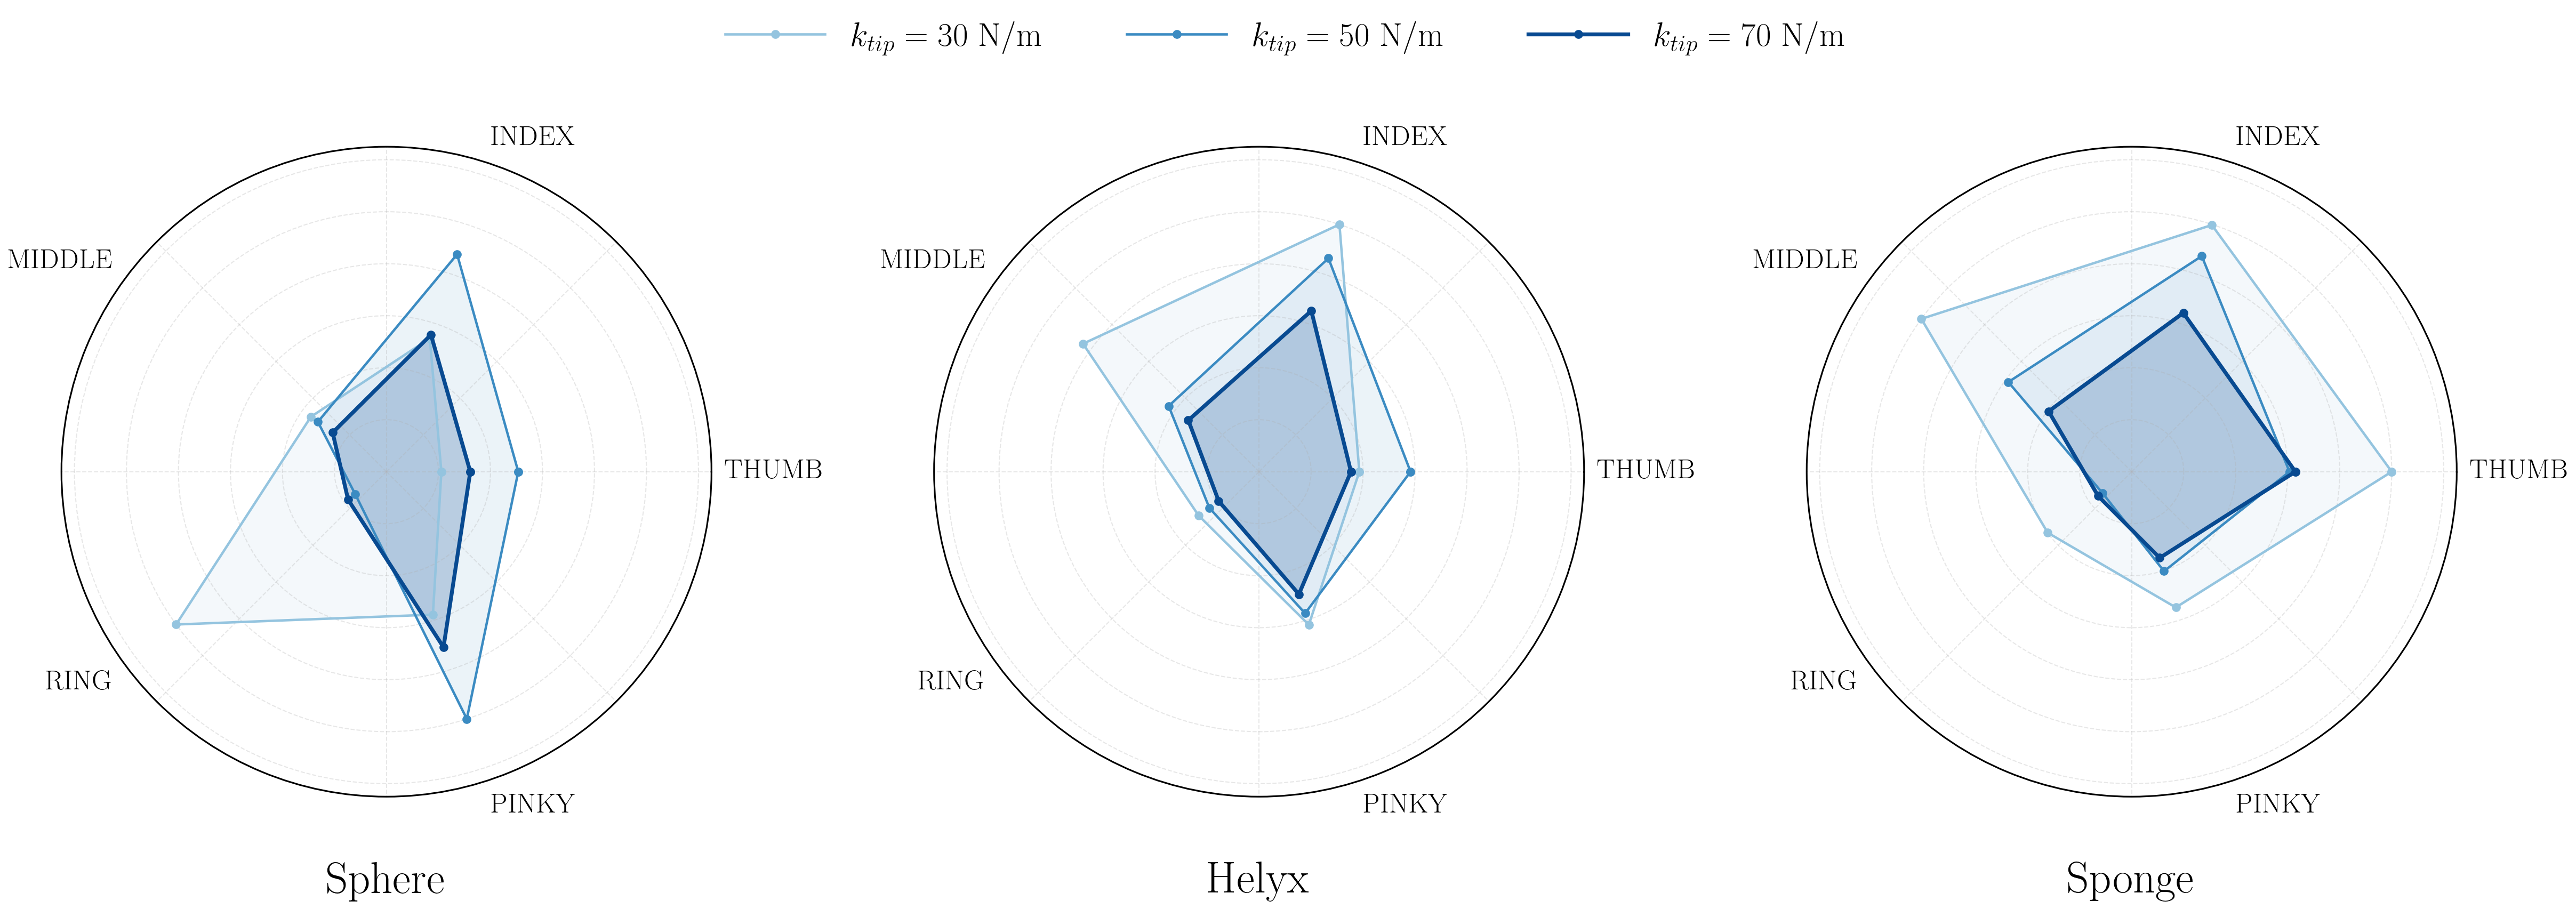

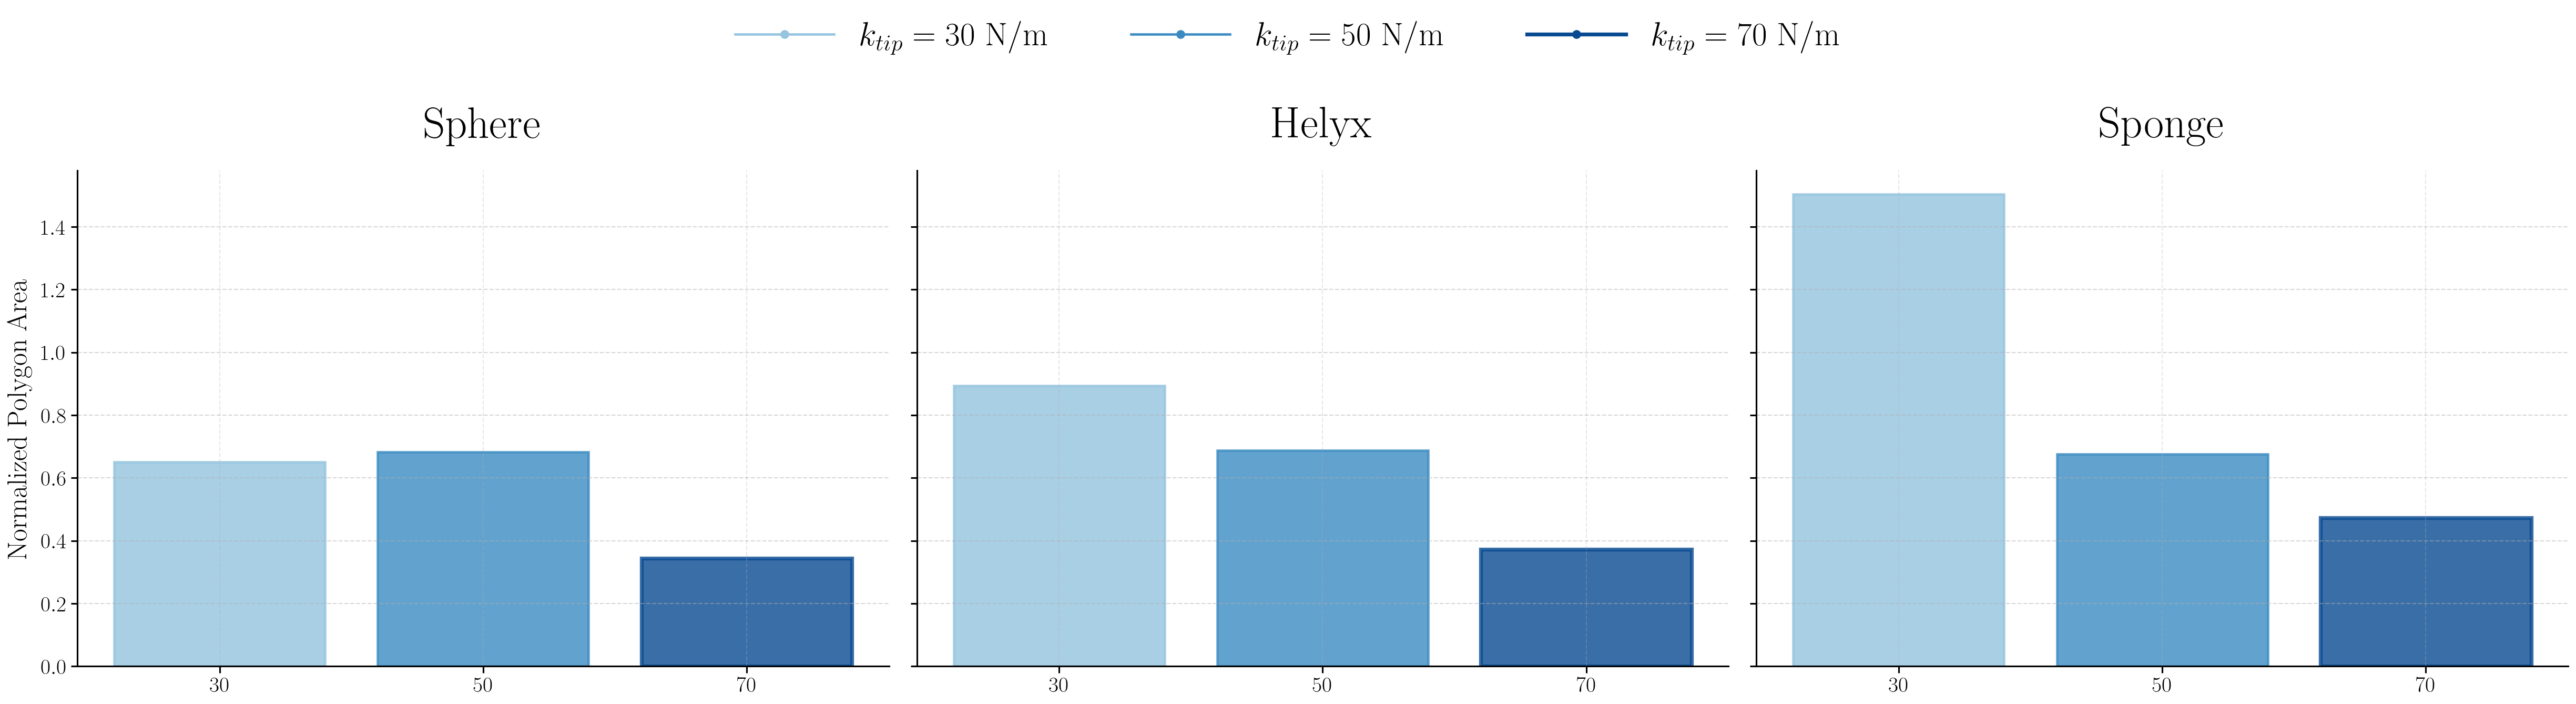

In [187]:
co_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    for f in FINGERS:
        k_arr, C_arr = object_compliance(data[obj]['ss'], f)
        for k, c in zip(k_arr, C_arr):
            co_raw[(obj, f, float(k))] = c

sweep_levels = sorted({k for _, _, k in co_raw})
draw_radar_fig(co_raw, sweep_levels,
               os.path.join(OUTPUT_DIR, 'radar_compliance.pdf'),
               cmap_name='Blues')


## Tip displacement per finger

FK tip displacement $\|\Delta x_f\| = \|p_f(k_{tip}) - p_f(k_{gentle})\|$ for each sweep level. Shows which fingers deflect most as the controller stiffens.

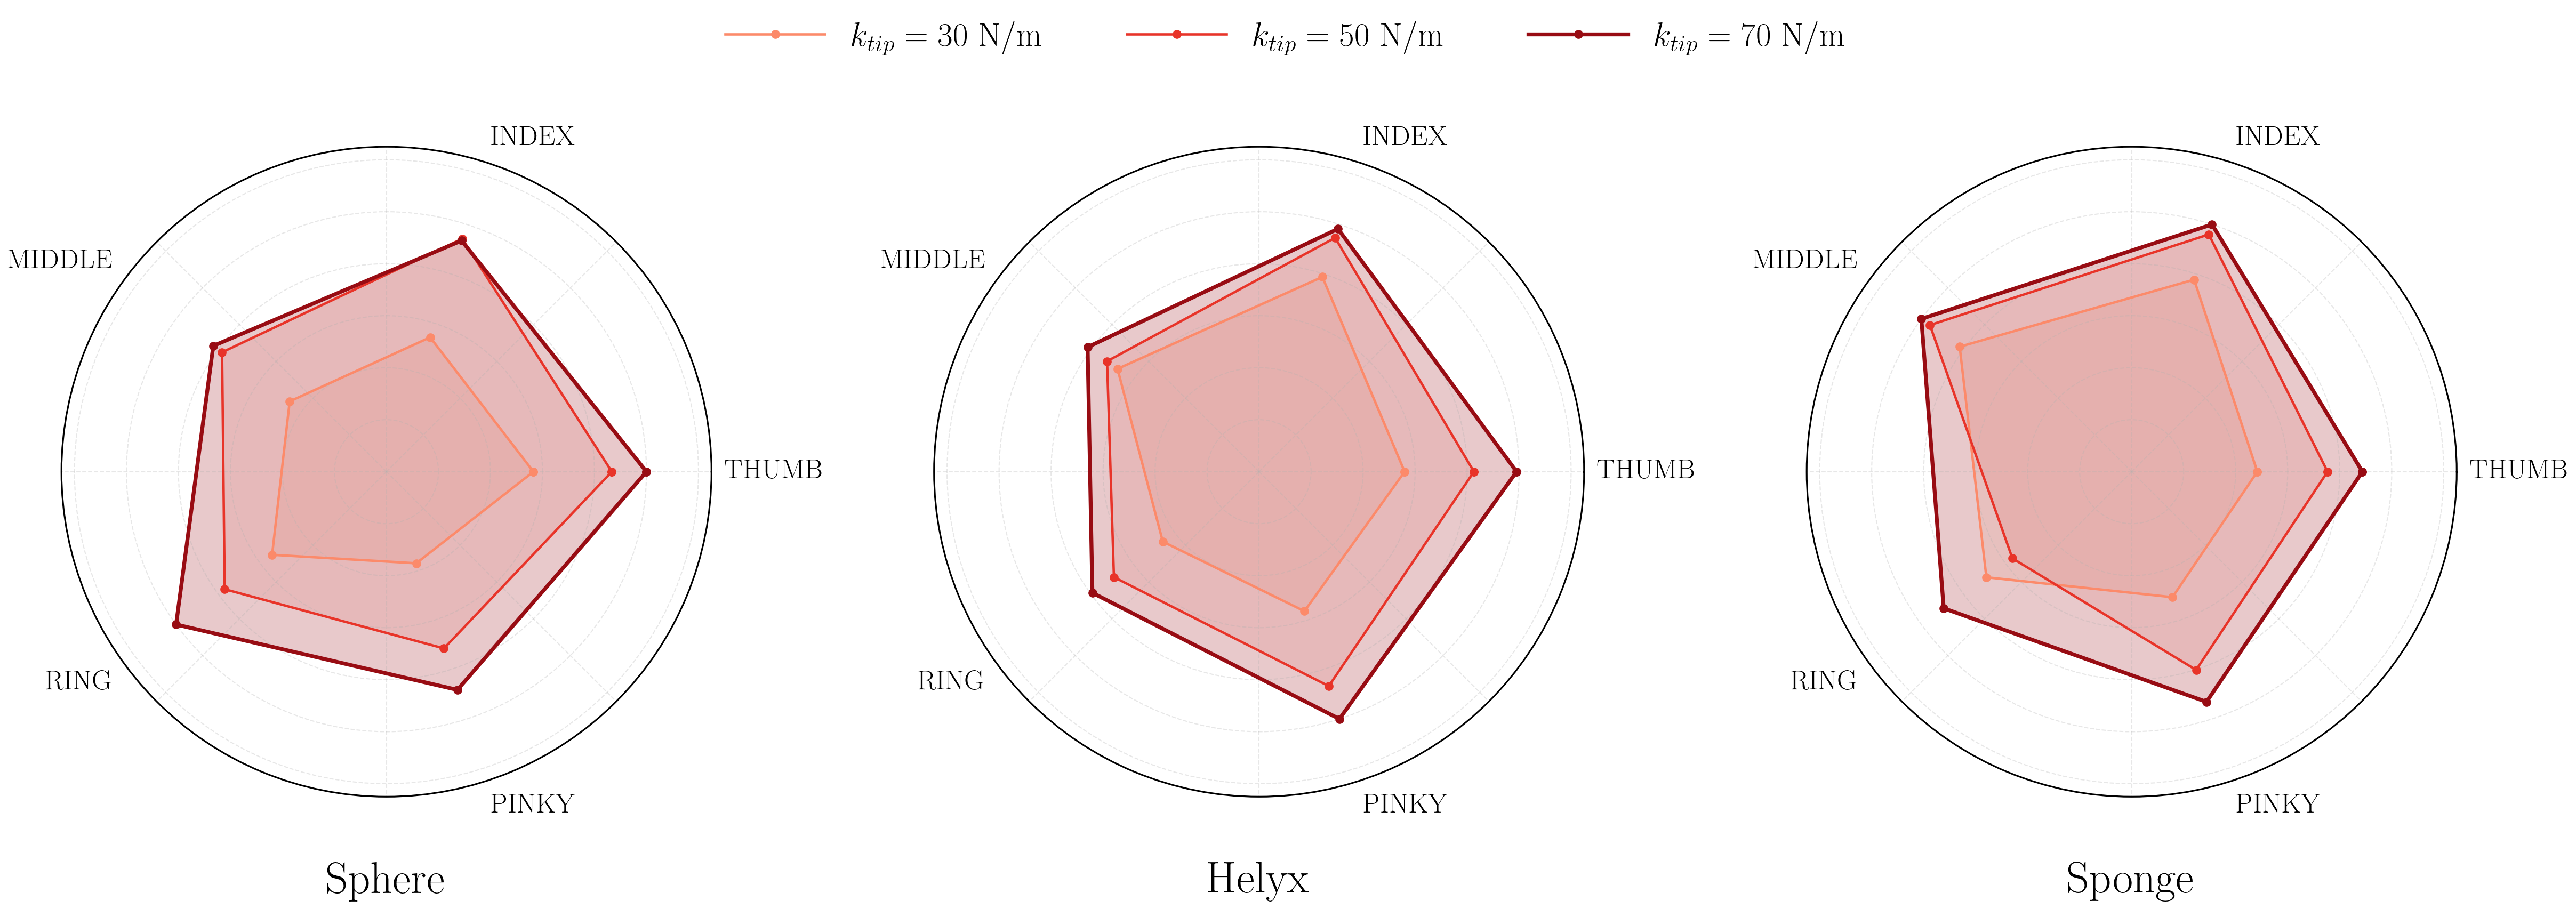

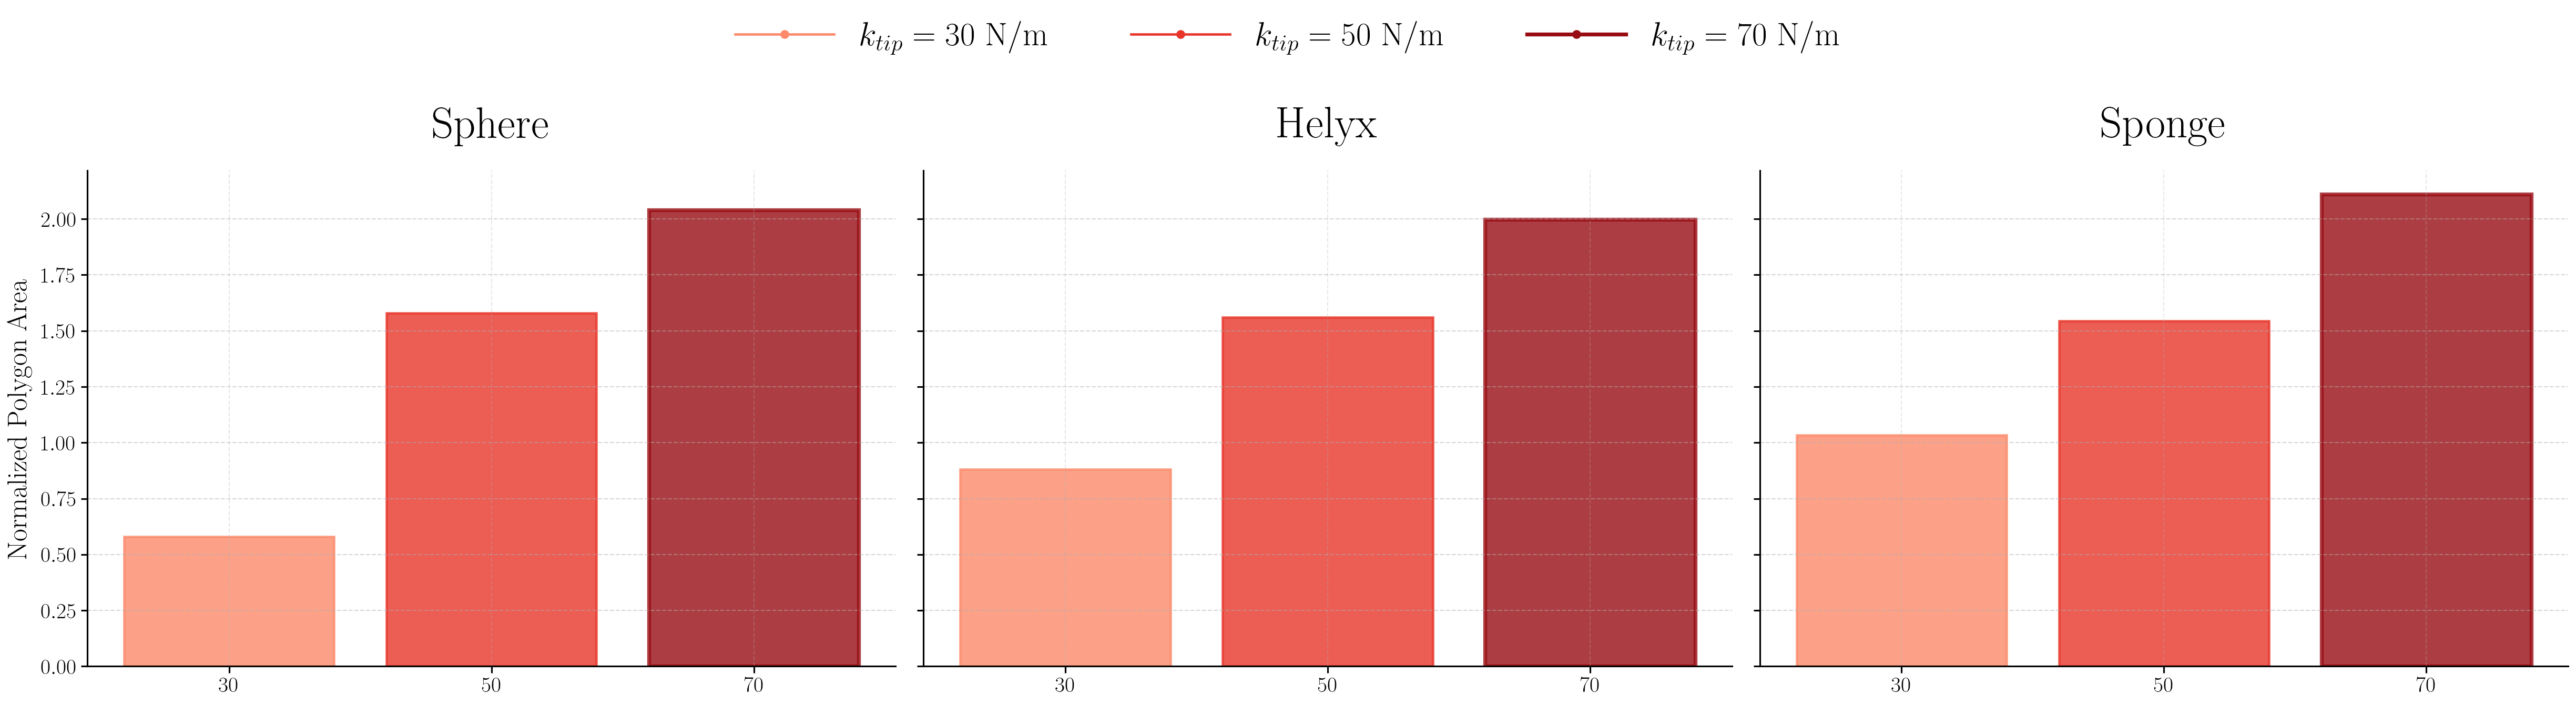

In [191]:
disp_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    ss   = data[obj]['ss']
    base = {f: ss[K_TIP_GENTLE][f]['pos'] for f in FINGERS}
    for k, per_f in ss.items():
        for f in FINGERS:
            disp_raw[(obj, f, float(k))] = np.linalg.norm(per_f[f]['pos'] - base[f])

disp_levels = sorted(k for k in {k for _, _, k in disp_raw} if abs(k - K_TIP_GENTLE) > 1e-6)
draw_radar_fig(disp_raw, disp_levels,
               os.path.join(OUTPUT_DIR, 'radar_displacement.pdf'),
               cmap_name='Reds', plot_area_bars=True)


## Contact force per finger

1st-order VMC force magnitude $\|F_f\|$ at each $k_{tip}$ level. Reveals the load distribution across fingers and how it evolves with controller stiffness.

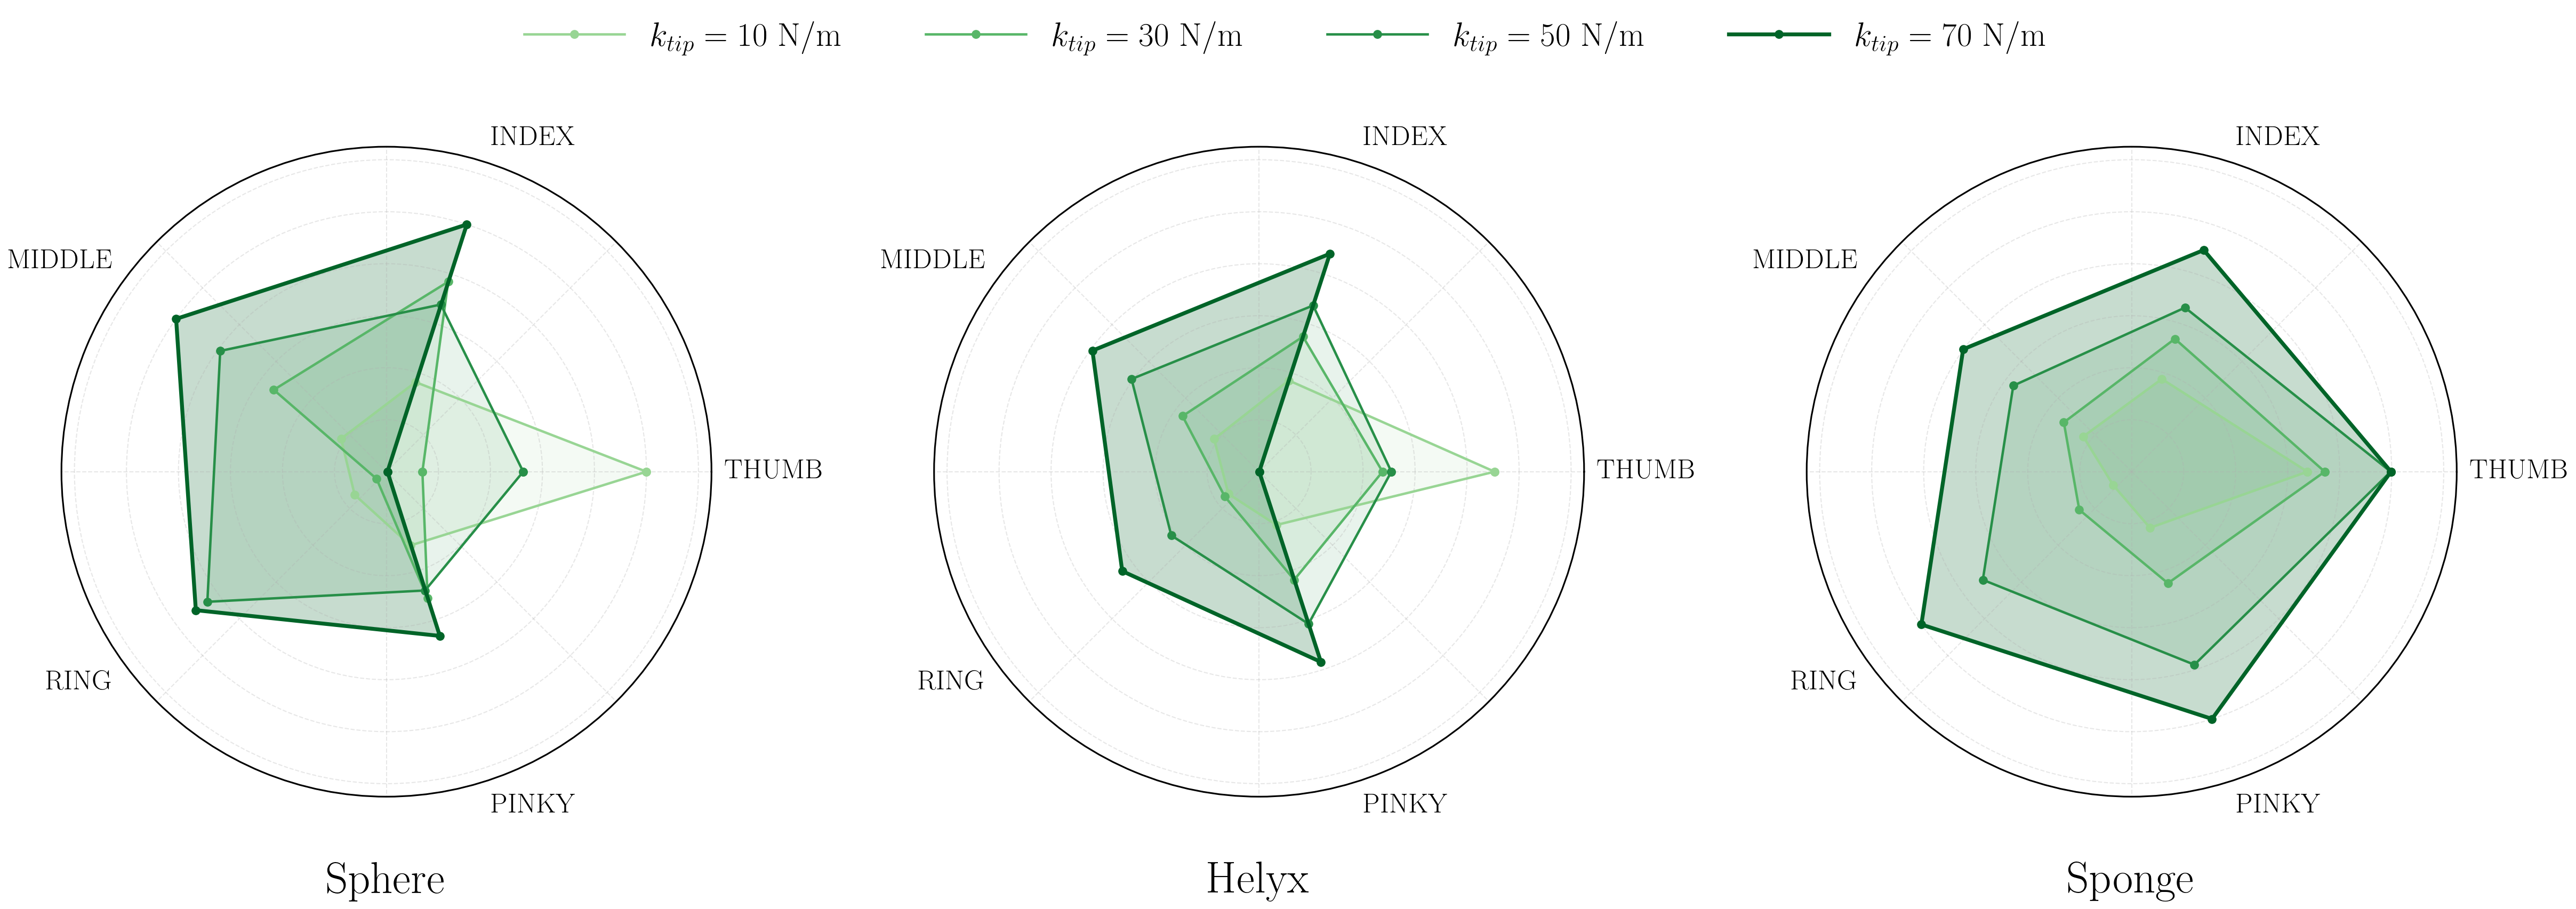

In [189]:
force_raw = {}
for obj in OBJECTS:
    if obj not in data:
        continue
    for k, per_f in data[obj]['ss'].items():
        for f in FINGERS:
            force_raw[(obj, f, float(k))] = np.linalg.norm(per_f[f]['F1'])

force_levels = sorted({k for _, _, k in force_raw})
draw_radar_fig(force_raw, force_levels,
               os.path.join(OUTPUT_DIR, 'radar_force.pdf'),
               cmap_name='Greens', plot_area_bars=False)


## Model compliance $C_A$ per finger

$C_A = 1/\lambda_{max}(K_x)$ at the gentle baseline ($k_{tip}=10$ N/m). Two layers: 1st-order model (blue) and 2nd-order CCT-corrected model (black). Per-finger normalization.

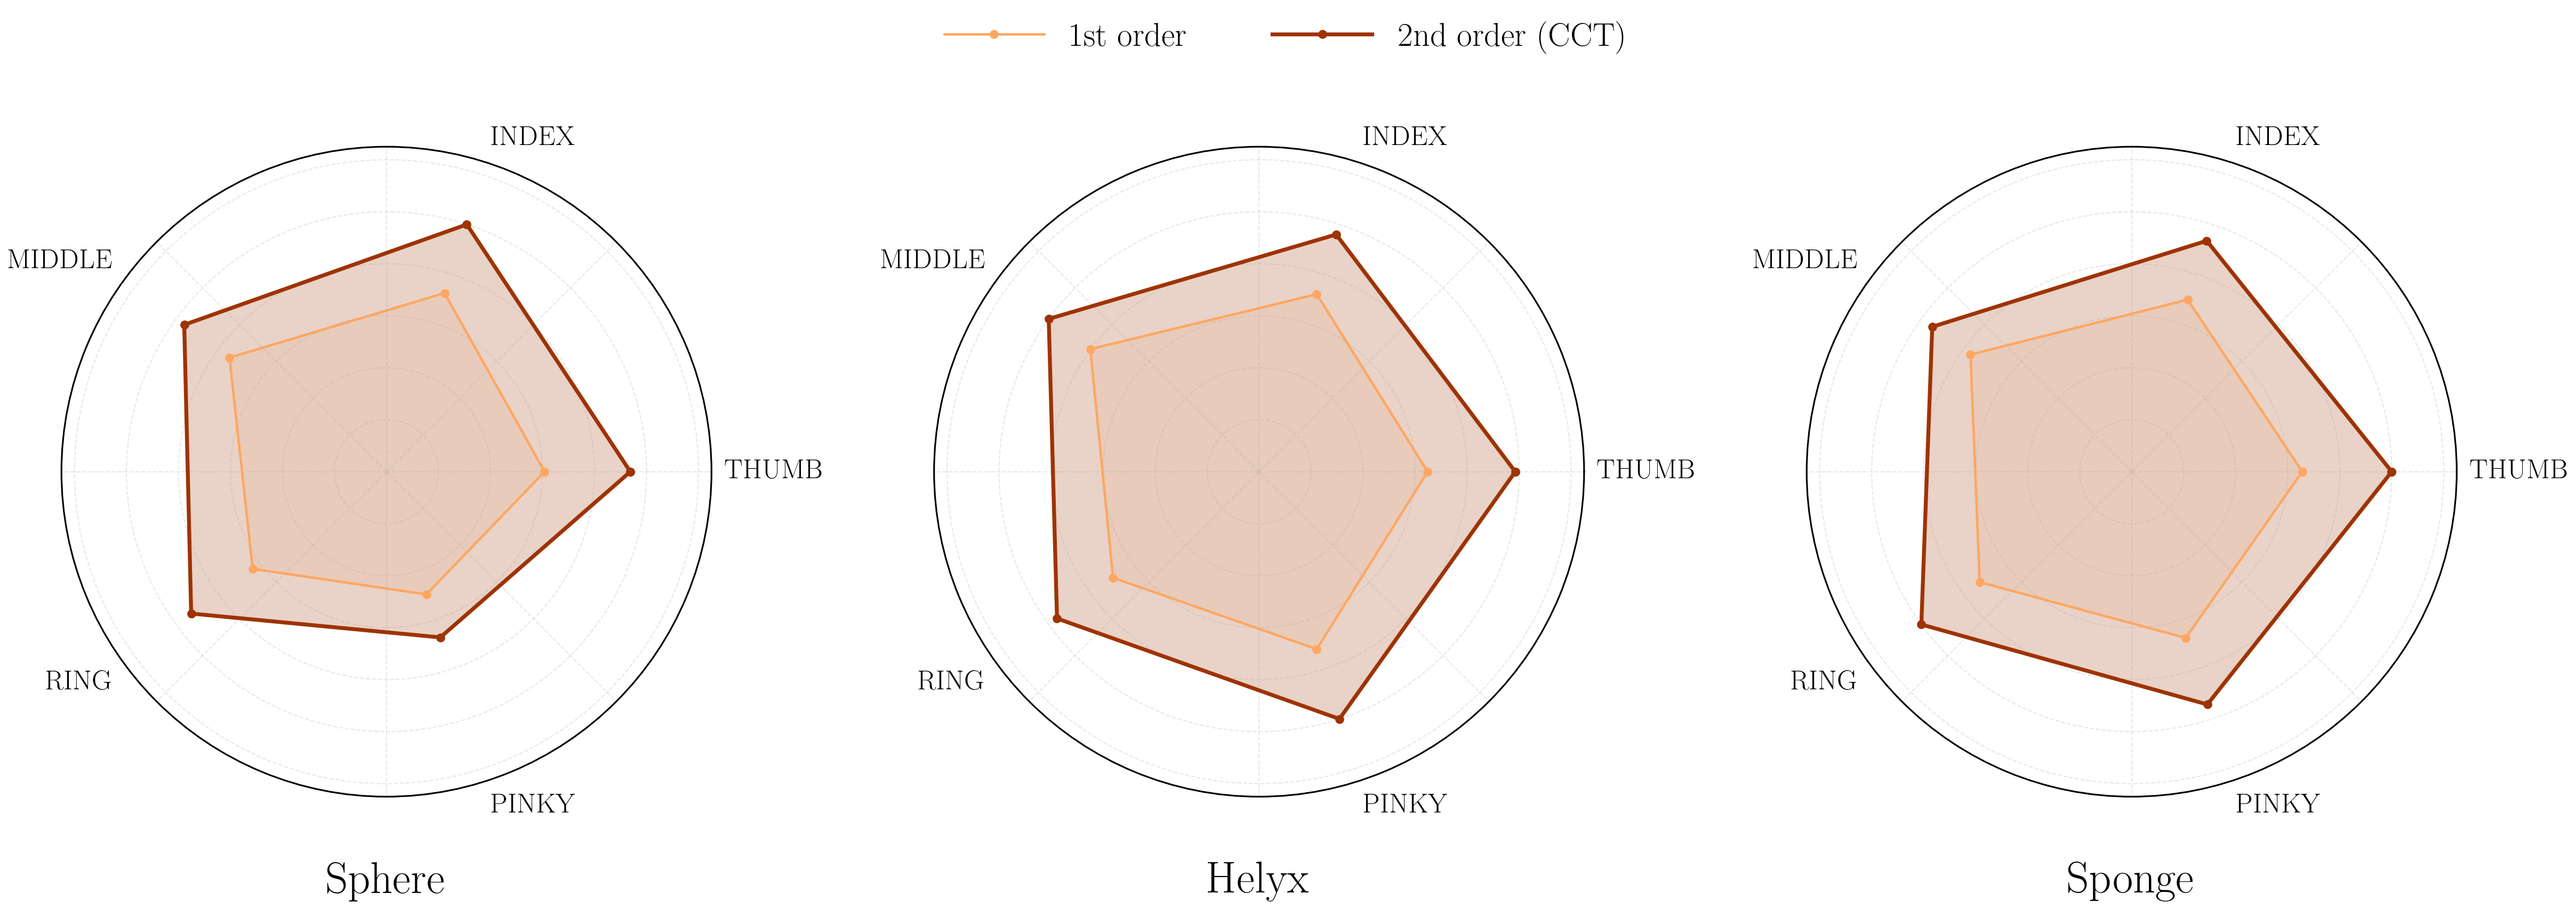

In [190]:
ca_raw = {}

for obj in OBJECTS:
    if obj not in data or K_TIP_GENTLE not in data[obj]['ss']:
        continue
    ss = data[obj]['ss']
    
    for f in FINGERS:
        e1 = ss[K_TIP_GENTLE][f]['eig1'].max()
        e2 = ss[K_TIP_GENTLE][f]['eig2'].max()
        
        ca_raw[(obj, f, '1st order')] = 1.0 / e1 if e1 > 1e-12 else np.nan
        ca_raw[(obj, f, '2nd order (CCT)')] = 1.0 / e2 if e2 > 1e-12 else np.nan

model_levels = ['1st order', '2nd order (CCT)']

draw_radar_fig(
    ca_raw, 
    model_levels,
    os.path.join(OUTPUT_DIR, 'radar_compliance_model.pdf'),
    cmap_name='Oranges', plot_area_bars=False
)